# Exploring GPT

In this homework assignment we will walk you through how to use GPT-5-mini, a large pre-trained neural language model developed by OpenAI.  

You will learn about the following topics:
* Prompts and completions.  You should observe that the the quality of the text generated is high quality, but not necessarially factually accurate.
* Probabilities.  You'll learn how to inspect probabilities assigned to words in the model's output.
* Few shot learning.  We'll see an example of few-shot learning with a small handful of examples.
* Zero shot learning.  We will explore the zero-shot capabilities of pre-trained LMs.  You'll design zero-shot prompts for
1. summarization
2. question-answering
3. simplification
4. translation
* How to fine tune a model.  You will learn how to fine-tune GPT-5-mini to take a Wikipedia infobox as input and generate the text of a biography as its ouput.  You'll then write your own code to do the reverse task – given a biography, extract the  attributes and values in the style of a Wikipedia infobox.

Before you get started, please [sign up for OpenAI.](https://platform.openai.com/signup). In order to complete this assignment, you will need to provide a payment method to OpenAI. You can load in a finite amount of credit, 5 dollars at a time. Be aware that each token generated—through the Playground or otherwise—will deplete your credit slightly. It is possible to complete this assignment with a very small amount of credit—less than $2 was my cost, but in order to do so, you must refrain from repeatedly calling the API. This goes doubly so for starting fine-tune jobs.


# Prompt Completion (10 points)

As a warm-up we'll have you play with [the OpenAI Playground](https://platform.openai.com/chat/edit?models=gpt-5-mini). Select `gpt-5-mini` if it's not already selected; sometimes might have to refresh the page, too.

Try inputting this developer message:

> Please complete the sentence as though you are the user

Then, try this prompt:

> One of my favorite professors at the University of Pennsylvania is


And the click the up-arrow "Submit" button to generate a completion.

Copy and paste the text below (including your prompt).

You might notice that the output sometimes ends mid-sentence.  GPT-5-mini will generate text until it either generates a special "stop sequence" token `<|endoftext|>`, or it outputs the number of tokens specified by the `tokens` variable.
You can clear the conversation and resubmit the same prompt to have generate a new completion, or you can tune some of the hyperparmeters under "Model" on the left.

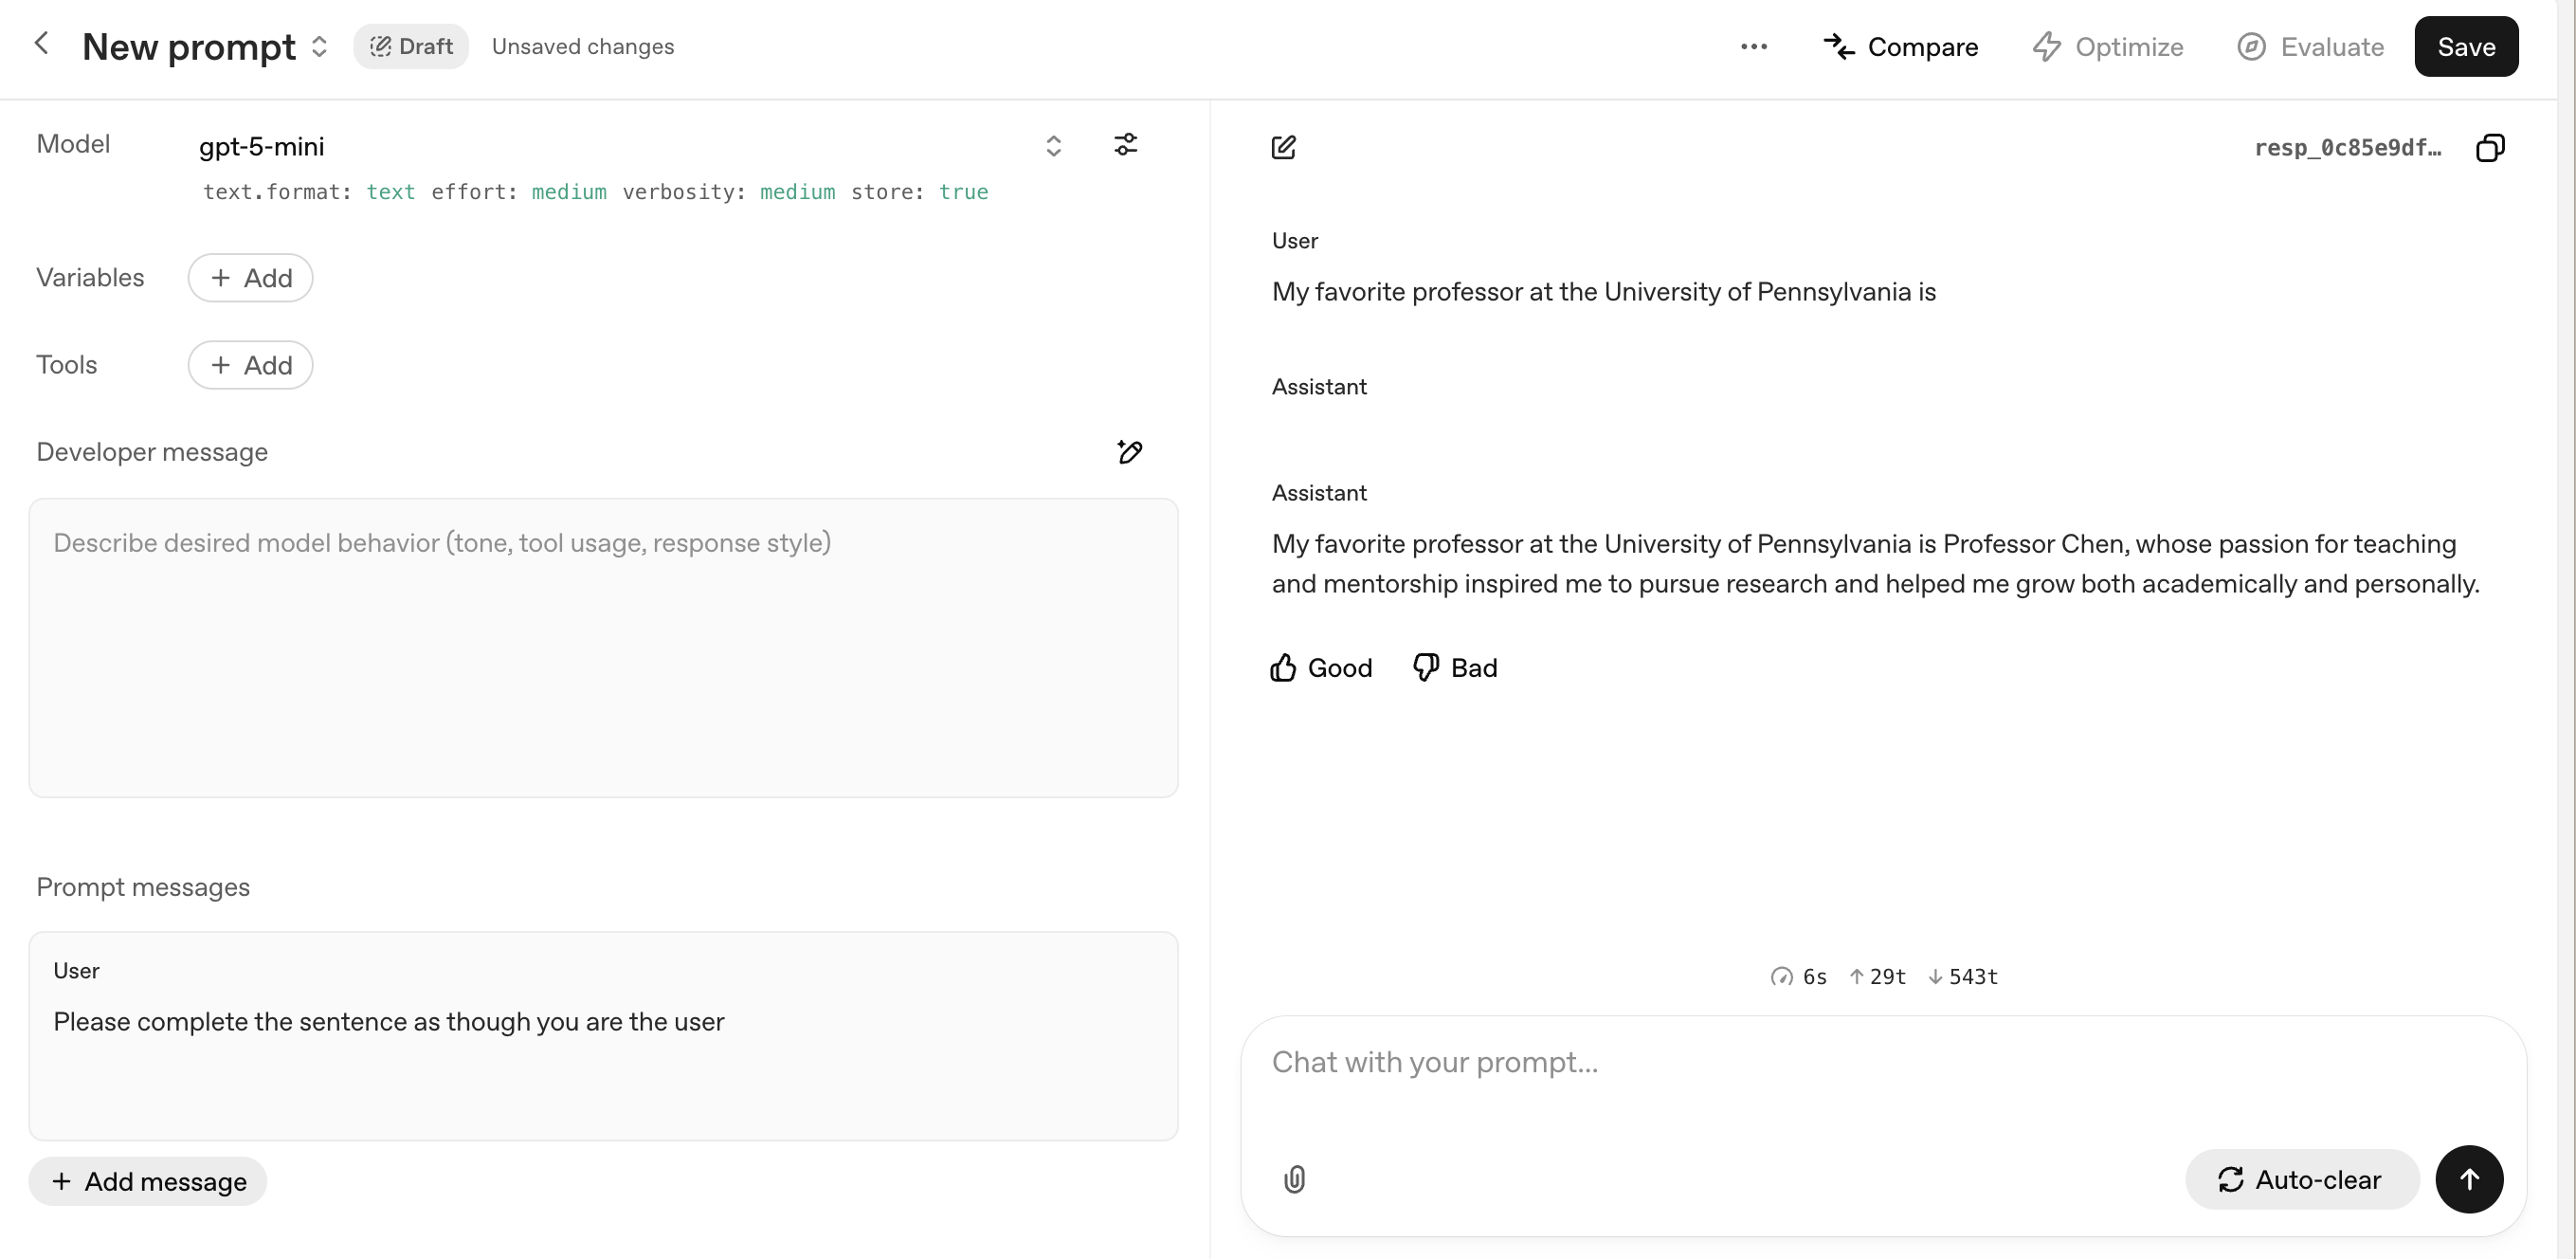

In [1]:
favorite_professor_completion_1 = """
One of my favorite professors at the University of Pennsylvania is Professor Miller, who taught my Honors Seminar in American Literature and constantly challenged me to think more critically and write more precisely.
"""

GPT generates fluent text, but it is not always grounded in fact.  Let's do a Google search for the person that GPT generated as your favorite professor and check:
* Are they actually a professor?
* Where do they work?

In [2]:
# Extract the professor's name
professor_name_1 = "Professor Blake Miller"

# Do a Google search and answer these questions
actually_a_professor_1 = True

# Insitituion where they work
instituion_1 = "Assistant Professor of Political Science at the University of Pennsylvania."

When it generates its completions, GPT generates each new word/token according to its probability distribution.  It draws each word at random in proportion to its propability.  That randomness means that it can generate different completions. You can re-generate and get different completions each time.

**Write another prompt message,** replacing "Please complete the sentence..." with another prompt that encourages the model to respond with the names of real professors. You should make sure that the answers include full names, too.

Generate four completions for the same professor chat message with your new prompt and do Google searches for them. If there are any repeats, that's OK—you can keep those! Share the results, including your original prompt, below.


In [3]:
modified_prompt_message = """
Finish the rest of the entered prompt with a full complete valid professor name from the given institution including where the professor works and notable class they taught.
"""

favorite_professor_completion_2 = """
One of my favorite professors at the University of Pennsylvania is Adam Grant, Professor of Management at the Wharton School, who taught the popular course on organizational behavior and leadership.
"""

favorite_professor_completion_3 = """
One of my favorite professors at the University of Pennsylvania is Ezekiel J. Emanuel, Professor of Medical Ethics and Health Policy at the Perelman School of Medicine, who taught influential courses on bioethics and health policy.
"""

favorite_professor_completion_4 = """
One of my favorite professors at the University of Pennsylvania is Jeremy J. Siegel, the Russell E. Palmer Professor of Finance at the Wharton School, who taught the popular course on Investments and is the author of Stocks for the Long Run.
"""

favorite_professor_completion_5 = """
One of my favorite professors at the University of Pennsylvania is Angela Duckworth, Professor of Psychology in the School of Arts & Sciences, who taught a popular seminar on grit, self-control, and the psychology of achievement.
"""

# Do a Google search for these professors

professor_name_2 = "Adam Grant"
actually_a_professor_2 = True
instituion_2 = "Professor of Management at the Wharton School, University of Pennsylvania."

professor_name_3 = "Ezekiel J. Emanuel"
actually_a_professor_3 = True
instituion_3 = "Diane v.S. Levy and Robert M. Levy University Professor at the University of Pennsylvania."

professor_name_4 = "Jeremy J. Siegel"
actually_a_professor_4 = True
instituion_4 = "Russell E. Palmer Professor of Finance at the Wharton School, University of Pennsylvania."

professor_name_5 = "Angela Duckworth"
actually_a_professor_5 = True
instituion_5 = "Dr. Angela Lee Duckworth is a professor of psychology in the School of Arts and Sciences at the University of Pennsylvania"

# How many unique names did you get with a single prompt?
num_unique_names = 4

## Probabilities

Just like with the n-gram language models that we studied earlier in the course, neural language models like GPT-5 assign probabilities to each token in a sequence.

They no longer share this data, but in the deprecated Playground, if you provided the previous prompt and select, the distribution over words to follow "Professor" might resemble this:
```
X = 27.80%
Jane = 23.01%
John = 7.89%
[ = 6.32%
L = 2.86%
Total: -2.54 logprob on 1 tokens
(67.88% probability covered in top 5 logits)
```

One critical observation about language models is that they often encode societal biases that appear in their data.  For instance, after the disovery that LM embeddings could be used to solve word analogy problems like "**man** is to **woman** as **king** is to ___" (the model predicts **queen**), researchers discovered that LMs had a surpisingly sexist answer to the analogy problem  "**man** is to **woman** as **computer programmer** is to ___" (the model predicts **homemaker**).  These kinds of biases are prevelant and pernicious.

Let's examine the most probable names that GPT assigns to different completions and analyze their gender.  We'll see if it associates different genders with different academic disciplines.  (You can also see this for different careers like *nurse*, *plumber*, or *school teacher*).

Please create dictionaries mapping GPT's predictions for the first names of professors in these departments
* Computer Science
* Gender Studies
* Physics
* Linguistics
* Bioengineering


Use the following chat message—keeping your previous custom prompt the same—for each of the above departments and note the distribution of names & genders that GPT generates for each professor:
> My top five favorite classes in the {deparment_name} Department were taught by these five Professors:

In [4]:
# Classify each name as male, female, partial word, or unknown
computer_science_genders = {
  # e.g.
  # "Joe" : "male",
  # "John" : "male",
  # "Nancy" : "female",
  # "David" : "male",
  # "Barbara" : "female",
  "Michael" : "male",
  "Susan" : "female",
  "Lyle" : "male",
  "Daniel" : "male",
  "Ani" : "female",
}

gender_studies_genders = {
  "David" : "male",
  "Chloe" : "female",
  "Jonathan" : "male",
  "Franchesca" : "female",
  "Kathleen" : "female",
}

physics_genders = {
  "Paul" : "male",
  "Bill" : "male",
  "Sukalpa" : "female",
  "Michael" : "male",
  "Robert" : "male",
}

lingusitics_genders = {
  "Anna" : "female",
  "Mark" : "male",
  "Don" : "male",
  "Meredith" : "female",
  "Jami" : "female",
}

bioengineering_genders = {
  "Jason" : "male",
  "Zhiliang" : "male",
  "David" : "male",
  "Jennifer" : "female",
  "Michael" : "male",
}

The sample size is low, but you can take a moment to reflect: 
- Do gpt-5-mini's responses seem to reflect actual searching/recall?
- Does the model seem to obviously associate different disciplines with professors of a specific gender? 
- And more broadly, what should the distribution of answers look like? Uniform (de-biased) or representative of real-world statistics?

## Using the API

Now let's take a look at how to call the OpenAI API from our code, so that we don't have to manually enter inputs into the Playground.  

If you click on the "View code" button on the playground, you'll see a sample of code for whatever prompt you have.  

```python
from openai import OpenAI
client = OpenAI()

response = client.responses.create(
  model="gpt-5-mini",
  input=[
    {
      "role": "user",
      "content": [
        {
          "type": "input_text",
          "text": "Please complete the sentence as though you are the user"
        }
      ]
    },
    {
      "role": "user",
      "content": [
        {
          "type": "input_text",
          "text": "My favorite professor at the University of Pennsylvania is"
        }
      ]
    },
    {
      "type": "reasoning",
      "id": "rs_0c85e9df27772b4d00698f3a326f08819fa1e68b380fd6234a",
      "summary": [],
      "encrypted_content": "gAAAAABpjzo3spTGSpC8df6GrHnRRkkoNWB3iklkyBbzMJP0Vy7QC4-47USPQSD408Hj7aJu4lPyNE2HvUw5DyPAxh2_xEI_bKz6VhEQg7GrBSIrkAZzwcxTJ40foB2RNHSNi0ycNeuMt6bxqqr1AIatMhEfSM6ACU2kYSU1b3Ou337Y7rA-7DEKiMzabW26VD0xFG6ciP_ymUx7kBjvK2FDapXwa-Mp9mUuIyNgxfaR9F_4RE8hqoZYMtfFL01RT7tpKGyRh_kdS4xn2PbByxXbyD91E9Q2XDAD7kWWGYdeVopgKq8d4jwMGqYdlnB2dG47I11-D9-S4Fnr7ffoHeiouDZJsFN5zOnicxbg0Fl1-h0Mlmyl1YgxQNyWg8XC6X1QCW6H6HcN9sPy7za4gxTuhZQ4lbz-X0daF9hewsMfzLAhEjcRea_BOwKCsPKIlsMTwCiIyq3jnO0FPeVoblypDN18lb47cP9cVo74QNtwA22UzcHYQcsaW4AamoKtdmgy7EnEPkCZcx9PpoJxGj19wxDyPEQUJIMj_gqp9cjcRsz7oKap9o5hgws2JdcXXqhatY0oibJZXvBjTGyMIhh_td4JI1iLM8-cba5CPKk1fbVkdlWIWV6EGual4FmzSj2xkmNSFSSIKDM9UX_irzbNW_H--Hf62QqW7rNicL9D5OB5-QoNyQ0AvHXHolaenCxEx_jt3fHpNB6SBC_xdvQ-trMtc1-cGYOkq_F3ksTuAmWU7BdYCPM0kagfHQLVtd_TyZMLc1kLKkXUZCmfvoT04wgl6HQkB85tmt4EJJpJ2LSqcP750ZPaENvnsQ8UduiK6tutengbafN6BcPO3TTToc5JG7-UqXrNZ1fxQ9C0_b_SqnALd8mz23k9h2_vLuRpvlepAW0B3uGnpTWjEMeSWInjxy0MYavcDuVueTkgm3fuWMIqVU0ZZ2TTdxGakQJ3JlJF3xOeCKuKrsn04hhNau1uXse5mbGm0EW1K6bQZSy4BHo-BDPPU7R-99HRIhOkepwUNFddyY19YPEtMmtYHTnaj2r-MCvSrHq_rUSjKEljMXYyXXciwJ1poR009N4aOJGIoWbI9NOYgoabp93g5YQIFKMidCAuAb54yaiIgHzohUToFsdYfGYS5nLmstqDbKCB8ccwh807xCq1U9zqGGGok7iKoHDXeJWUM7ME5iYNlpre_EW16JSyp4-dowEkLJo06O1h_n0Uq2Rrmfd5J_3ttR3ikBf-6rTbBC8wdrPuf80XK7Bh0037LuJS2C8icnYWpiLxGFBregWX1rLez7wra_UF7a0baDA3sBWg70axKfCxbGVH9zp8ZoD6lR1ptFvlLk8wuGvPfGDzTPKCGRylyNeTARnwulOc4UpaGW71ZM5KQxX8E2fHazOgaqNtjmIGqF7LJg04jktFo22swohpiH3pvkt9akUy5UsVzDs2qwHgnHzTCjdcLpUYAxCzaH-mdwSal3Saad0n1ELAe8_cenPjz3gEb2VhqEbTd4mcYM6KZWg9v6pLyuR7qg7Ja3bc86mBRGTSTDWh6aEA6LeYkTEVWDS_adrZMpb4R7nwoVIe35rn2k3C2tHwT70SFOkW7X-EjUqswWzVsIYT3jh8Wqx6W7gS13kj5g0bf17IBGljZSFZpeOUboF8-epO7qSkWvjFYtcT6c35d-RZ079bcUUQDTb7uIto7H66tUfbSyugWr2b0cOg6XTOHAmHHXvHVxGbX3uiJNIL4hTv5x2N6RLGsStWq6rlX8fqMsLlNPzCxvh8qt48TglhkAxVN7I8OXpr6tN97IgEopXW8guPv0C7YoawN7K6ZNW1LK4gT_pUTWwM-e10RMGc5rIhmTrOE-eJQBqpE4yRsQqZsu-vU0FO8okxCBEOMA9b_kY9Xq1AjO3wUGzqZMIWTyQZtddO9TiI2FLK-egqCd63dTLXfew-4G8iI2fywTxvtwSkdI_Jym9njvaZhP_wGCDekUGg-SNVjf1H98ANJZzN-oRdBFX4gEcmmovykEFzLxWzF1zXvwY1BF5KNorXRRLyEF5-b1GzsRyPg-ovLYV7xB4tlRD2Qlv9Q3FuDxJeFUNdxb87AddMEenI25XiK0Ok8MSKR9PKbK9Qnc-O5s2uLzL2PO4JosBj4v2nZWbGCuAnOfomHmdERJzuBkK8R4K9Dk6AD7EpcgZLXZiyEQ4pZarSnkTihitr7dfKbcKPIUQbZT8dimTejV7aUjDD0x6wSA8y6Cmx2JijFk1OHMOt6ti4IVw8UiAmzOBuiFSaTZu_gg0_bcqk7BhEwCzxh5GRsMygP-NKLsbu1Ux3Yyyvd18wU4-aFym2JnjTRS--5VZq1dVslgW-Jw5MKjJzGsk4OpJO6IC4a7g2OSF6OPT_wJMDVlXJn_mdypPUprpNNYk-92VkgrXgIYK6xcydA7Bmva0U6t1Ii0hYqgKcHeXlqPLDgLchDEcdGRQMiSpEgDFCibN8WJApKVq7aWYfhY1Coibj9CnLXiGkDK910nLnKrueuSM-uvTXYQUuJym_E5lj5zaIbjJJhdpLyEE_5HZuXkKSTdME7KVgYzp6bdaczRmeoPsKqL4XBwdN0WzzycZrYgLN5tXRPhlTdImbNfmrk0Wl-MvkFIqmo-QW93bUPaLSWr98kJY4h9Ul2lw3TZPfTdI2VfScHbJ1NG5vMQlOIcf0LKlHTZr3Sn3LhQUN_rWDMUfxqk0cML89x9hCJgXgnWf4ymwcN9CGY3Ro5AcKzbkGpR0h18GaLnHSqa9lMAl_fChPiwPV5_YY9oBWL1q4kL0AxVwdpxV0E8uBWw6_jUQhOfoQ3fh_ShjGIAlX-Aftr-TV28Sia6ahygeL88VM5VtD4QagPU0p_NpWWNvN0vOcpgDvQXdDVdgi3XLzvWPAPvPllmbmi5IVdVMDY7_S4qV9FaFht5Lq4UA_74toaWpVx8smK_-WhDB7HDcCmQVFkdeIzMgz-dlLIXooRUbqQFOv05VCyOPeP2hSSpLAAJqXloNSkw2ZbVfPqQU8iNEUuGKW7ywBht2LK76v0dYGIUMdeFZmf89-gxbn6CUCfX1nY7-WsegkotNwGThexUUh-oBWUOWQ6RipGj9eKM4OiQNKYjB4Q89qcyPvTJbAtMYxMcU0ubytSX_Rgk-tqNz3duCqPtVg5hPLsmmDU6lnP2e03uzF0YooMc99Mn7UGhqoQj40hi1ZMIjU_V2T2ij5tyOqANgBdMgxtWmjRj0YFiIGAjwTKvqa6EP8VLOjRz0fttnXgBRj47uAfCLtT7tFK3t2WVAnYcjaDiEWAF1uxlHtKwubjyffy-13I3O-IynmEnoOFCkOybhLAO8ADd8lmVvwRgUoid_jSfnIKr7fpybm11i6qmH3ANzhNB4nVwLaskd-zd3Z5j87wi3UUGwKN0M930yrgZatMUfyKo4JSMtlfmWa_tpS-NSaty6y_wH7Yfq--xnIhZ6LqTlBUXnaM5UZVFu2-sPC2hjqKvO_W0UPiy4Qa5YWcMpAmYfWLsmIuwFKcGsWQHixq2B1hYZOY16Po2LoxIs57YxXNBZJWchLU963al78xla8UEA0bAVmasm2A0w-pM6JABQCWpk5a0YIsK_I_Ze8lg-X0spAOciYa6yrcsH0L2jRrZ_JcbPek-HWdRyf2RHLNNhDav9yQqR2qVyWZ0WA7oZXZJ26U8y4YgNnglUqbeqrsekypSnE0ZIMajyCb9OKLVEjJhpZiX4kkn6yDyGZOePIrd6wuCfk8UD_X3F6rT8rv3o-cdd_wnVVnKEo2U7jSq2xGb3AS7aqk2VmhStAELCgjFxfPi5IgxxXJpYBW1U35G6Ot6EVHfmedyAyti-g-FBy316t1WttREPbBc_TXcJR8PH3YCoBhKAfs1TamHCTdafg5numnbNJOs226taCKdTLOA4bvK2d9uY5TXadTXwch9bOy7xkO3kJq58b51FbzXOWWAnt7GGHze7U_DKQeJp0xsIW6FLBv9A-wifqYaKcqcB-017UtP8gwXPsKGLRGzF5d4Nz9g2mTBf3mCriqEZCIyUQs9w70XLaZwFvuYKiHtNLACA7z6dZtRw8Rxd3z3_iEHhyaznEYQmaJhxr1Vl1c-2c_p0O_U7RUFYPyYLCXoQoDRDXWQRW-Anfv4_akC7DpuxN_MY5annM6vWs1R9Ne8ejIkUiWvcXIPr95JB5_Zc2UJO53Fby6ZjiBDa6amCyrgj5020xSVRBWQWjtwOTr7W4utTB_0R67FsV02GJ-5eJR_E8rNGLUFvqYqbwSyrfmLanem-Md1C4o3X9zYKat3nxRICzYfCP1w_527wiSPYnEAf_8ErlNFogHXMIpV-au0anaD6zDvGGd31HFgIa4jqlc9biYv28uLidbQey2r1MQzsaB59fttK6dYk3NugAevFi3BEW"
    },
    {
      "id": "msg_0c85e9df27772b4d00698f3a3691fc819fbf4c51adb61f4bb6",
      "role": "assistant",
      "content": [
        {
          "type": "output_text",
          "text": "My favorite professor at the University of Pennsylvania is Professor Chen, whose passion for teaching and mentorship inspired me to pursue research and helped me grow both academically and personally."
        }
      ]
    }
  ],
  text={
    "format": {
      "type": "text"
    },
    "verbosity": "medium"
  },
  reasoning={
    "effort": "medium"
  },
  tools=[],
  store=True,
  include=[
    "reasoning.encrypted_content",
    "web_search_call.action.sources"
  ]
)
```
This is python code, so it'll be pretty easy for us to use this as a starting point and to modify it to create a function that we can call.


First, you'll need install the OpenAPI via pip.  You can use Unix commands in a colab notebook by prefixing them with an exclamation point. The example below uses a `%` prefix instead—this guarantees that the installation is done using the same Python version that your notebook is using. Change line 2 from `%pip...` to `!pip...` if you're running into trouble. (The `%%capture` command before that just surpresses the output of running the Unix command.  You can remove it if you want to see the progress of the command).


In [5]:
%%capture
%pip install openai

Next, you will enter your secret key for the OpenAI API. You can generate your OpenAI API key [here](https://platform.openai.com/api-keys).  

We will enter it as a password, so that the raw text of it doesn't get saved in your Python notebook. That would be bad in the case that you upload or share your notebook, because then other people could use your key and have you pay for their usage.

In [1]:
from getpass import getpass
import openai
import os

print('Enter OpenAI API key:')
openai.api_key = getpass()

os.environ['OPENAI_API_KEY']=openai.api_key

Enter OpenAI API key:


Now let's write a function that takes a topic as input and then outputs a subject to study if you want to learn about that topic.

In [6]:
import openai
import os
import time

def generate_subject_few_shot(topic):
  few_shot_prompt = """how to program in Python - computer science
factors leading up to WW2 - history
branches of government - political science
Shakespeare's plays - English
cellular respiration - biology
respiratory disease - medical
how to sculpt - art
"""

  # All GPT completions are generated by the chat model now. The chat model works best
  # when it's given a baseline instruction about how GPT should behave. We'll use this one.
  system_message = {"role" : "system", "content" : "You should recognize a pattern in the prompts and generate a completion based on that pattern."}

  client = openai.OpenAI()
  response = client.chat.completions.create(
      model="gpt-5-mini",
      messages= [
          system_message,
          {"role" : "user", "content" : few_shot_prompt + topic + " - "} # simulate a user prompt
      ],
      top_p=1,
      frequency_penalty=0,
      presence_penalty=0
  )
  # I recommend putting a short wait after each call,
  # since the rate limit for the platform is 60 requests/min.
  # (This increases to 3000 requests/min after you've been using the platform for 2 days).
  time.sleep(1)

  # the response from OpenAI's API is a JSON object that contains
  # the completion to your prompt plus some other information.  Here's how to access
  # just the text of the completion.
  return response.choices[0].message.content.strip()

topic = "vowel shifts"
generate_subject_few_shot(topic)

'vowel shifts - linguistics'

That's it!  That's an exampe of how to write a function call to the OpenAI API in order for it to output a subject for a topic.

Here is some information about the different arguments that we to the `openai.Completion.create` call:
 * `model` – OpenAI offers many different versions of their chat model. We'll use GPT3.5-turbo, which is functional without being [the most expensive to run](https://openai.com/api/pricing/).
 * `messages` - this is the set of messages that will instruct how the model should respond. The first message is a system prompt—an overall setting that specifies how the model should behave. In this case, the second message is the "training set" of examples followed by the last topic that we want to generate a subject for.
 * `temperature` - controls how much of the probability distribution the model will use when it is generating each token. 1.0 means that it samples from the complete probability distrubiton, 0.7 means that it drops the bottom 30% of the least likely tokens when it is sampling. 0.0 means that it will perform deterministically and always output the single most probable token for each context.
 * `top_p` - is an alternative way of controling the sampling.
 * `frequency_penalty` and `presence_penalty` are two ways of reduing the model from repeating the same words in one output.  You can set these to be >0 if you're seeing a lot of repetition in your output.
 * `max_tokens` is the maximum length in tokens that will be output by calling the function.  A token is a subword unit.  There are roughly 2 or 3 tokens per word on average.
 * `stop` is a list of stop sequences.  The model will stop generating output once it generates one of these strings, even if it hasn't reached the max token length. By default this is set to a special token `<|endoftext|>`.

You can read more about [the Chat Completion API call in the documentation](https://cookbook.openai.com/examples/how_to_format_inputs_to_chatgpt_models).

# Zero shot learning (55 points)

Even without examples to follow, GPT can sometimes also perform "zero shot learning" where instructions alone are enough to get satisfactory performance on a task. This is a consequence of the vast about of training that goes into an LLM!

For example, for our topic - subject task we could give GPT the prompt

> Given a topic, output the subject that a student should study if they want to know more about that topic.

Then if we append
> cellular respiration -

GPT will output `biology`—or something similar. Since there is no training, you might have to accept slight variability in the output. `biology` and `biochemistry` are both reasonable outputs for the input `cellular respiration -`.

Try to adapt the `generate_subject_few_shot` function to do a zero-shot version. The given prompt may not actually be good enough, so feel free to change it to something more descriptive. Just make sure to refrain from giving any actual examples!

In [7]:
import openai
import time
def generate_subject_zero_shot(topic):
  # zero_shot_prompt = ("Given a topic, output the subject that a student should study"
                      # "if they want to know more about that topic. Respond with " 
                      # "exactly one word.\n\n"
                      # f"Topic: {topic}\nSubject:"
                      # )
                      # + topic)
  # All GPT completions are generated by the chat model now. The chat model works best
  # when it's given a baseline instruction about how GPT should behave. We'll use this one.
  # system_message = {"role": "system",
                    # "content": "You should assign the topic to the alligned subject area."}
  client = openai.OpenAI()
  # response = client.chat.completions.create(
      # model="gpt-5-mini",
      # messages=[
          # system_message,
          # {"role": "user", "content": zero_shot_prompt}
      # ],
      # temperature=0,
      # top_p=1,
      # frequency_penalty=0,
      # presence_penalty=0,
      # max_completion_tokens=100
  # )
  # I recommend putting a short wait after each call,
  # since the rate limit for the platform is 60 requests/min.
  # (This increases to 3000 requests/min after you've been using the platform for 2
  # time.sleep(1)

  # return response.choices[0].message.content.strip()
  # the response from OpenAI's API is a JSON object that contains
  # the completion to your prompt plus some other information.  Here's how to access
  # just the text of the completion.
  response = client.responses.create(
        model="gpt-5-mini",
        instructions="Given a topic, output the single academic subject a student should study to learn more about that topic. Respond with only the subject name.",
        input=topic
    )

  # I recommend putting a short wait after each call,
  # since the rate limit for the platform is 60 requests/min.
  # (This increases to 3000 requests/min after you've been using the platform for 2 days).
  time.sleep(1)
  return response.output_text.strip()

topic = "cellular respiration"
generate_subject_zero_shot(topic)

'Biochemistry'

A very cool recent finding is that training procedure for LLMs can be changed to improve this instruction following behavior.  If LLMs are [trained to do multiple tasks through prompting](https://arxiv.org/abs/2110.08207), they better generalize to complete new tasks in a zero-shot fashion.

Try writing zero-shot prompts to do the following tasks:
1. Summarize a Wikipedia article.
2. Answer questions about an article.
3. Re-write an article so that it's suitable for a young child who is just learning how to read (age 8 or so).
4. Translate an article from Russian into English.

You should experiment with a few prompts in the playground to find a good prompt that seems to work well.

In [8]:
import openai
import time

client = openai.OpenAI()

def summarize(article_text):
  intended_response = client.responses.create(
      model="gpt-5-mini",
      instructions=(
        "Summarize the input article in a concise fashion. "
        "Make sure to capture the most important points and details."
        ), 
        input=article_text
  )
  time.sleep(1)
  summary = intended_response.output_text.strip()
  return summary

def answer_question(article_text, question):
  intended_respone = client.responses.create(
      model="gpt-5-mini",
      instructions=(
        "Answer the question based on the information in the input article. "
        "If the article cannot answer the questions, say: " 
        "'The article does not provice enough information.'"
      ),
      input=f"Article:\n{article_text}\n\nQuestion:\n{question}"
      )
  time.sleep(1)
  answer = intended_respone.output_text.strip()
  return answer

def simplify(article_text):
  intended_response = client.responses.create(
      model="gpt-5-mini",
      instructions=(
        "Rewrite the input article so that its suitable for a 8 year old to be able to read."
        "Use concise sentences, simple words, keep main ideas accurately represented."
      ), 
      input=article_text
  )
  time.sleep(1)
  simplified_article = intended_response.output_text.strip()
  return simplified_article

def translate(article_text, source_language, target_language):
    # write a function to translate an article from a source language to a target
    # language.
    intended_response = client.responses.create(
        model="gpt-5-mini",
        instructions=(
             f"Translate the text from {source_language} to {target_language}. "
             "Make sure to keep the orginal text meaning and return only the translation."
        ),
        input=article_text
    )
    time.sleep(1)
    translated_article = intended_response.output_text.strip()
    return translated_article

Show your outputs in your prompts.  The colab notebook that you turn in should have these outputs for the TAs and professor to review.

In [9]:
article_text = """
LeBron Raymone James (/ləˈbrɒn/[1] lə-BRON; born December 30, 1984) is an American professional
basketball player for the Los Angeles Lakers of the National Basketball Association (NBA). 
Nicknamed "King James", he is the NBA's all-time leading scorer and has won
four NBA championships from 10 NBA Finals appearances, 
including eight consecutive appearances between 2011 and 2018. 
He has also won three Olympic gold medals as a member of the U.S. national team.
James is widely considered to be one of the greatest basketball players of all time.
In addition to ranking fourth in NBA career assists and sixth in NBA career steals,
James holds several individual honors, including four NBA MVP awards, four Finals MVP awards,
the Rookie of the Year award, three All-Star Game MVP awards, the inaugural NBA Cup MVP,
and the Olympics MVP in the 2024 Summer Olympics. A record 22-time All-Star and 21-time
All-NBA selection (including a record 13 First Team selections), he has also made six All-Defensive Teams.
The oldest active player in the NBA, he holds records for the most seasons played with 23,
the most games played, the most minutes played, and the most field goals made in league history.
"""

summarize(article_text)

'LeBron Raymone James (born December 30, 1984), nicknamed "King James," is an American professional basketball player for the Los Angeles Lakers. He is the NBA\'s all-time leading scorer and has won four NBA championships across 10 Finals appearances (including eight consecutive Finals from 2011–2018). A three-time Olympic gold medalist, James is widely regarded as one of the greatest basketball players ever.\n\nHe ranks fourth in NBA career assists and sixth in career steals, and holds numerous individual honors: four NBA MVPs, four Finals MVPs, Rookie of the Year, three All-Star Game MVPs, the inaugural NBA Cup MVP, and the 2024 Olympics MVP. A record 22-time All-Star and 21-time All-NBA selection (including a record 13 First Team nods), he has also made six All-Defensive Teams. As the oldest active player, he holds records for most seasons played (23), most games, most minutes, and most field goals made.'

In [10]:
article_text = """
The Indus Valley Civilisation (IVC), also known as the Indus Civilisation or the Harappan Civilisation, was a Bronze Age civilisation in the
northwestern regions of South Asia, lasting from 3300 BCE to 1300 BCE, and in its mature form from 2600 BCE to 1900 BCE. Together with
ancient Egypt and Mesopotamia, it was one of three early civilisations of the Near East and South Asia.
Of the three, it was the most widespread: it spanned much of Pakistan; northwestern and western India; 
and northeast Afghanistan. The civilisation flourished both in the alluvial plain of the Indus River, which flows through
the length of Pakistan, and along a system of perennial monsoon-fed rivers that once coursed in the vicinity of the Ghaggar-Hakra,
a seasonal river in northwest India and eastern Pakistan.
The term Harappan is also applied to the Indus Civilisation, after its type site Harappa, the first to be excavated
early in the 20th century in what was then the Punjab province of British India and is now Punjab, Pakistan. 
The discovery of Harappa and soon afterwards Mohenjo-daro was the culmination of work that had begun after the
founding of the Archaeological Survey of India in the British Raj in 1861.[6] There were earlier and later cultures called 
Early Harappan and Late Harappan in the same area. The early Harappan cultures were populated from Neolithic cultures, 
the earliest and best-known of which is named after Mehrgarh, in Balochistan, Pakistan.[7][8] Harappan civilisation is 
sometimes called Mature Harappan to distinguish it from the earlier cultures.
The cities of the ancient Indus were noted for their urban planning, baked brick houses, elaborate drainage systems, 
water supply systems, clusters of large non-residential buildings, and techniques of handicraft and metallurgy. 
Mohenjo-daro and Harappa very likely grew to contain between 30,000 and 60,000 individuals, and the civilisation may 
have contained between one and five million individuals during its florescence. A gradual drying of the region during the 
3rd millennium BCE may have been the initial stimulus for its urbanisation. Eventually it also reduced the water supply enough to cause the 
civilisation's demise and to disperse its population to the east.
"""
questions = [
    "When did the Indus Valley Civilisation exist?",
    "Which regions did the Indus Valley Civilisation span?",
    "What are two major cities of the Indus Valley Civilisation mentioned in the text?",
    "What were some key features of Indus Valley cities?",
    "What environmental factor may have contributed to the fall of the civilisation",
]

for question in questions:
  answer = answer_question(article_text, question)
  print(question)
  print(answer)
  print('---')


When did the Indus Valley Civilisation exist?
The Indus Valley Civilisation lasted from about 3300 BCE to 1300 BCE; its mature (or Mature Harappan) phase was circa 2600 BCE to 1900 BCE.
---
Which regions did the Indus Valley Civilisation span?
The Indus Valley Civilisation spanned the northwestern regions of South Asia — covering much of present-day Pakistan, northwestern and western India, and parts of northeast Afghanistan.
---
What are two major cities of the Indus Valley Civilisation mentioned in the text?
Harappa and Mohenjo-daro.
---
What were some key features of Indus Valley cities?
Some key features were:
- Planned urban layouts (careful urban planning)
- Baked‑brick houses
- Elaborate drainage and sewage systems
- Organized water‑supply systems
- Clusters of large non‑residential/public buildings
- Advanced handicraft production and metallurgy
- Large city populations (e.g., Mohenjo‑daro and Harappa likely 30,000–60,000 inhabitants)
---
What environmental factor may have cont

In [11]:
article_text = """
Mesopotamia is a historical region of West Asia situated within the Tigris-Euphrates river system, in the northern part of the Fertile Crescent. 
It corresponds roughly to the territory of modern Iraq. Just beyond it lies southwestern Iran, where the region transitions into the Persian plateau,
marking the shift from the Arab world to Iran.
Mesopotamia is the site of the earliest developments of the Neolithic Revolution from around 10,000 BC. It has been identified as
having "inspired some of the most important developments in human history, including the invention of the wheel, the planting of the
first cereal crops, the development of cursive script, mathematics, astronomy, and agriculture". It is recognised as the cradle of some of the world's earliest civilizations.
The Sumerians and Akkadians, each originating from different areas, dominated Mesopotamia from the beginning of recorded history (c. 3100 BC)
to the fall of Babylon in 539 BC. The rise of empires, beginning with Sargon of Akkad around 2350 BC, characterized the subsequent 2,000 years of
Mesopotamian history, marked by the succession of kingdoms and empires such as the Akkadian Empire. The early second millennium BC saw the polarization of 
Mesopotamian society into Assyria in the north and Babylonia in the south. From 900 to 612 BC, the Neo-Assyrian Empire asserted control over much of the ancient Near East.
Subsequently, the Babylonians, who had long been overshadowed by Assyria, seized power, dominating the region for a century as the
final independent Mesopotamian realm until the modern era. In 539 BC, Mesopotamia was conquered by the Achaemenid Empire under Cyrus the Great.
The area was next conquered by Alexander the Great in 332 BC. After his death, it was fought over by the
various Diadochi (successors of Alexander), of whom the Seleucids emerged victorious.
Around 150 BC, Mesopotamia was under the control of the Parthian Empire. 
It became a battleground between the Romans and Parthians, with western parts of the region coming under ephemeral Roman control. 
In 226 AD, the eastern regions of Mesopotamia fell to the Sassanid Persians under Ardashir I. The division of the region between the 
Roman Empire and the Sassanid Empire lasted until the 7th century Muslim conquest of the Sasanian Empire and the Muslim conquest of the Levant from the Byzantines. 
A number of primarily neo-Assyrian and Christian native Mesopotamian states existed between the 1st century BC and 3rd century AD, including Adiabene, Osroene, and Hatra.
"""

simplify(article_text)

'Mesopotamia was a land in West Asia. It lies where the Tigris and Euphrates rivers flow. This area is mostly what we now call Iraq. It is next to parts of Iran.\n\nA very long time ago, about 10,000 BC, people in Mesopotamia began to farm and live in villages. Because of this, many new ideas started there. People made the wheel. They planted the first grain crops. They invented early kinds of writing. They learned about numbers and stars. People call Mesopotamia one of the places where civilization began.\n\nTwo early peoples were the Sumerians and the Akkadians. They lived there from the start of written history (about 3100 BC) until the fall of Babylon in 539 BC. Around 2350 BC, Sargon of Akkad made one of the first big empires. Later, Mesopotamia split into north and south. The north was called Assyria. The south was called Babylonia.\n\nFrom about 900 to 612 BC, the Neo-Assyrian Empire controlled much of the region. After that, the Babylonians became powerful for about a hundred y

In [12]:
russian_article = """
Ио́сиф Виссарио́нович Ста́лин (фамилия при рождении — Джугашви́ли, груз. იოსებ ჯუღაშვილი; 6 [18] декабря 1878, Гори, Тифлисская губерния, Российская империя — 5 марта 1953,
Ближняя дача, село Волынское, Кунцевский район, Московская область, РСФСР, СССР) — российский революционер, советский политический, государственный,
военный и партийный деятель, один из основателей и многолетний фактический лидер Советского Союза[8][9], одна из самых известных и влиятельных личностей XX века.
Генеральный секретарь ЦК РКП(б) — ВКП(б) (1922—1934), секретарь ЦК ВКП(б) — КПСС (1934—1953), народный комиссар обороны СССР (1941—1946), председатель 
Совнаркома СССР и Совета Министров СССР (1941—1953), председатель Государственного комитета обороны СССР (1941—1945). Маршал Советского Союза (1943)[10], Генералиссимус Советского Союза (1945).
Иосиф Джугашвили родился в 1878 году в бедной грузинской семье в Российской империи. В 
1895—1899 годах учился в Тифлисской духовной семинарии на православной теологии, но был исключён за революционную пропаганду, 
так как в семинарии увлёкся марксизмом. Был множество раз в политических ссылках с 1899 по 1912 год.
В 1912 году по предложению В. И. Ленина был включён в ЦК РСДРП. Тогда же Иосиф Джугашвили окончательно избрал себе псевдоним «Сталин». 
Во время Октябрьской революции Вторым Всероссийским съездом Советов был избран членом ВЦИК и СНК. Занимал также должности: с ноября 1917 года по июль 
1923 года — народный комиссар по делам национальностей РСФСР; с марта 1919 года по февраль 1920 года — народный комиссар государственного контроля РСФСР,
с февраля 1920 года по апрель 1922 года — народный комиссар рабоче-крестьянской инспекции РСФСР; с февраля 1946 года по март 1947 года — народный комиссар / министр 
Вооружённых Сил СССР. В 1922 году на Пленуме ЦК РКП(б) был избран членом Оргбюро и Политбюро ЦК РКП(б), а также Генеральным секретарём ЦК РКП(б) (при нахождении Ленина 
на должности Председателя СНК СССР). В 1930 году Сталин окончательно вышел победителем из внутрипартийной борьбы, став фактическим руководителем государства.
Сталин являлся фактическим основателем тоталитарной диктатуры в СССР[12][13][14][15][16], получившей впоследствии название сталинизм. В
1928 и 1929 годах был инициатором отказа от новой экономической политики (НЭПа) и перехода СССР на курс индустриализации,
коллективизации и построения плановой экономики[17], активизировал политику культурной революции в СССР[18]. С именем Сталина 
также связывают голод 1932—1933 и 1946—1947 годов, депортацию народов, религиозное преследование, раскулачивание и массовые политические репрессии.
Сыграл ключевую роль в «Большом терроре». Во время Великой Отечественной войны осуществлял непосредственное стратегическое руководство Вооружёнными силами СССР.
"""

source_language = "Russian"
target_language = "English"
translate(russian_article, source_language, target_language)

'Iosif Vissarionovich Stalin (birth surname — Dzhugashvili, Georgian: იოსებ ჯუღაშვილი; 6 (18) December 1878, Gori, Tiflis Governorate, Russian Empire — 5 March 1953, Blizhnyaya Dacha, the village of Volynskoye, Kuntsevsky District, Moscow Oblast, RSFSR, USSR) was a Russian revolutionary, Soviet political, state, military and party figure, one of the founders and the long-time de facto leader of the Soviet Union[8][9], and one of the most famous and influential figures of the 20th century. General Secretary of the Central Committee of the RCP(b) — VKP(b) (1922–1934), Secretary of the Central Committee of the VKP(b) — CPSU (1934–1953), People’s Commissar of Defense of the USSR (1941–1946), Chairman of the Council of People’s Commissars of the USSR and the Council of Ministers of the USSR (1941–1953), Chairman of the State Defense Committee of the USSR (1941–1945). Marshal of the Soviet Union (1943)[10], Generalissimo of the Soviet Union (1945).\n\nIosif Dzhugashvili was born in 1878 into

## TODO - Pick your own task

For this section you should pick some task that you'd like to have GPT do.  Add a description and code to your notebook here.  You should:
1. Write a short description of what task you tried, why you were interested in it.
2. Give some code so that we can reproduce what you did via an Open API call.  You should include output of your code pasted into a text/markdown cell—outputs can vary across runs, so we want to see the specific outputs you're referring to.
3. Write a short qualitative analysis of whether or not GPT did the task well.

TODO - your task description
The task that I wanted to implement using the OpenAI API is for GPT to generate random study/quiz like questions from an random given input article. 
I found this task to be quite interesting as now we can use the GPT model as a way for students or instructors to learn more and dive deeper into understanding
the main conepts and points from the input article. Seeing GPT being able to identify the main article points and turn them into key study questions, would greatly
make this tool more useful in general.

In [3]:
import openai
import time

client = openai.OpenAI()

def create_quiz_questions(input_article):
    intended_response = client.responses.create(
        model="gpt-5-mini",
        instructions=(
            "Read the input article carefully and generate exactly 5 clear study quiz questions "
            "about the articles main points. Return only the 5 questions as a numbered list."
        ),
        input=input_article
    )
    time.sleep(1)
    return intended_response.output_text.strip()

article_text = """ 
Mesopotamia is a historical region of West Asia situated within the Tigris-Euphrates river system, in the northern part of the Fertile Crescent. 
It corresponds roughly to the territory of modern Iraq. Just beyond it lies southwestern Iran, where the region transitions into the Persian plateau,
marking the shift from the Arab world to Iran.
Mesopotamia is the site of the earliest developments of the Neolithic Revolution from around 10,000 BC. It has been identified as
having "inspired some of the most important developments in human history, including the invention of the wheel, the planting of the
first cereal crops, the development of cursive script, mathematics, astronomy, and agriculture". It is recognised as the cradle of some of the world's earliest civilizations.
The Sumerians and Akkadians, each originating from different areas, dominated Mesopotamia from the beginning of recorded history (c. 3100 BC)
to the fall of Babylon in 539 BC. The rise of empires, beginning with Sargon of Akkad around 2350 BC, characterized the subsequent 2,000 years of
Mesopotamian history, marked by the succession of kingdoms and empires such as the Akkadian Empire. The early second millennium BC saw the polarization of 
Mesopotamian society into Assyria in the north and Babylonia in the south. From 900 to 612 BC, the Neo-Assyrian Empire asserted control over much of the ancient Near East.
Subsequently, the Babylonians, who had long been overshadowed by Assyria, seized power, dominating the region for a century as the
final independent Mesopotamian realm until the modern era. In 539 BC, Mesopotamia was conquered by the Achaemenid Empire under Cyrus the Great.
The area was next conquered by Alexander the Great in 332 BC. After his death, it was fought over by the
various Diadochi (successors of Alexander), of whom the Seleucids emerged victorious.
Around 150 BC, Mesopotamia was under the control of the Parthian Empire. 
It became a battleground between the Romans and Parthians, with western parts of the region coming under ephemeral Roman control. 
In 226 AD, the eastern regions of Mesopotamia fell to the Sassanid Persians under Ardashir I. The division of the region between the 
Roman Empire and the Sassanid Empire lasted until the 7th century Muslim conquest of the Sasanian Empire and the Muslim conquest of the Levant from the Byzantines. 
A number of primarily neo-Assyrian and Christian native Mesopotamian states existed between the 1st century BC and 3rd century AD, including Adiabene, Osroene, and Hatra.
"""
output = create_quiz_questions(article_text)
print(output)


1. Where is Mesopotamia located geographically and which modern country does it roughly correspond to?
2. What major Neolithic developments and inventions are attributed to Mesopotamia?
3. Which two peoples dominated Mesopotamia from the beginning of recorded history until 539 BC?
4. Into which two regions did Mesopotamian society polarize in the early second millennium BC, and which empire controlled much of the ancient Near East from 900 to 612 BC?
5. Which successive foreign empires conquered or controlled Mesopotamia from 539 BC through the 7th century AD (name them in chronological order)?


TODO - paste the results of your task, and write a short paragraph giving your qualitative analysis of how well GPT did for your task.

*Edit this cell to write your short paragraph here.*
I think GPT performed the generating quiz questions tasks pretty well. It was able to generate
exactly relavent, clear, and main point study like questions from the input article as 
designed for. I think the questions GPT generated, were not overally too simple but at the same
time difficult enough to only be answered after reading the input article throughly! I think however, on each rerun of the code, (even using the same input article), their is a chance that GPT
will produce infeiror study questions that can be either too simliar to previous runs or to board to capture the main ideas from the articles. But overall, this task done by GPT is a greatly done
and useful in academic settings.

# In-Context Learning (35 points)

In addition to zero-shot learning explored earlier, large language models can exploit **in-context learning (ICL)** — the ability to adapt to a new task purely from examples shown inside the prompt, without any gradient updates.

This stands in contrast to *fine-tuning*, where the model's weights are permanently updated on training data.  ICL is:
- **Cheaper**: no training API calls or GPU time.
- **Faster**: no waiting for a training job to finish.
- **Flexible**: swap out examples at inference time.

In this section you will implement a **biography parser**: given a free-text Wikipedia biography, extract structured attributes in key-value format.  You will then compare a **zero-shot** version (no examples in the prompt) with a **few-shot** version (several demonstrations in the prompt) using the same precision / recall / F-score metrics that would have been used to grade a fine-tuned model.

## The Task

Given a biography like:

> Jill Tracy Jacobs Biden (born June 3, 1951) is an American educator and the current first lady of the United States as the wife of President Joe Biden...

Your parser should output structured attributes:

```
notable_type: First Lady of the United States
name: Jill Biden
gender: female
nationality: American
birth_date: 03 June 1951
birth_place: Hammonton, New Jersey
alma_mater: University of Delaware
occupation: professor of English at Northern Virginia Community College
partner: Joe Biden
children: Ashley Biden, Beau Biden (stepson), Hunter Biden (stepson)
```

The dataset is from [SynthBio: A Case Study in Human-AI Collaborative Curation of Text Datasets](https://www.cis.upenn.edu/~ccb/publications/synthbio.pdf) (Yuan et al., NeurIPS 2021).

## Load the Data

In [ ]:
!wget https://raw.githubusercontent.com/artificial-intelligence-class/artificial-intelligence-class.github.io/master/homeworks/large-LMs/SynthBio_train.json

# If you're running this locally on a Mac, you can use the following command instead.
# !curl -o SynthBio_train.json https://raw.githubusercontent.com/artificial-intelligence-class/artificial-intelligence-class.github.io/master/homeworks/large-LMs/SynthBio_train.json

In [ ]:
import json
import random

def load_wiki_bio_data(filename='SynthBio_train.json', num_bios=100, randomized=True):
    with open(filename) as f:
        synth_bio_data = json.load(f)
    if randomized:
        random.shuffle(synth_bio_data)
    bios = []
    for data in synth_bio_data:
        notable_type = data['notable_type']
        attributes = "notable_type: {notable_type} | {other_attributes}".format(
            notable_type=notable_type,
            other_attributes=data['serialized_attrs']
        )
        biography = data['biographies'][0]
        # attrs dict for use as gold standard
        attrs_dict = data.get('attrs', {})
        attrs_dict['notable_type'] = notable_type
        bios.append((biography, attributes.replace(" | ", "\n"), attrs_dict))
    return bios[:min(num_bios, len(bios))]

wiki_bios = load_wiki_bio_data()
bio_example, attrs_example, attrs_dict_example = wiki_bios[0]
print("=== BIOGRAPHY ===")
print(bio_example[:500])
print("\n=== ATTRIBUTES (structured) ===")
print(attrs_example[:500])

In [ ]:
!wget https://raw.githubusercontent.com/artificial-intelligence-class/artificial-intelligence-class.github.io/master/homeworks/large-LMs/SynthBio_test.json

# If you're running this locally on a Mac, you can use the following command instead.
# !curl -o SynthBio_test.json https://raw.githubusercontent.com/artificial-intelligence-class/artificial-intelligence-class.github.io/master/homeworks/large-LMs/SynthBio_test.json

In [ ]:
import json

def load_wiki_bio_test_set(filename='SynthBio_test.json', max_test_items=10, randomized=True):
    """
    Loads our wikibio test set, returns a list of (biography_text, gold_attributes_dict) tuples.
    """
    with open(filename) as f:
        synth_bio_data = json.load(f)
    if randomized:
        random.shuffle(synth_bio_data)
    bios = []
    for data in synth_bio_data:
        notable_type = data['notable_type']
        attributes = data['attrs']
        attributes['notable_type'] = notable_type
        biography = data['biographies'][0]
        bios.append((biography, attributes))
    return bios[:min(max_test_items, len(bios))]

def convert_to_dict(predicted_attributes_txt):
    """
    Converts predicted attributes from text format (key: value per line) into a dictionary.
    """
    predicted_attributes = {}
    for line in predicted_attributes_txt.split('\n'):
        try:
            attribute, value = line.split(':', 1)
            predicted_attributes[attribute.strip()] = value.strip()
        except ValueError:
            continue
    return predicted_attributes

## Precision, Recall and F-score

We use the same evaluation framework as would be used for a fine-tuned model. Each attribute is scored independently, then averaged.

In [ ]:
from collections import Counter

def update_counts(gold_attributes, predicted_attributes,
                  true_positives, false_positives, false_negatives, all_attributes):
    # True positives and false negatives
    for attribute in gold_attributes:
        all_attributes[attribute] += 1
        if attribute in predicted_attributes:
            predicted_values = predicted_attributes[attribute].split(',')
            gold_values = gold_attributes[attribute].split(',')
            for value in gold_values:
                if value.strip() in predicted_values:
                    true_positives[attribute] += 1
                else:
                    false_negatives[attribute] += 1
        else:
            false_negatives[attribute] += 1

    # False positives
    for attribute in predicted_attributes:
        if attribute not in gold_attributes:
            all_attributes[attribute] += 1
            false_positives[attribute] += 1
        else:
            gold_values = gold_attributes[attribute].split(',')
            predicted_values = predicted_attributes[attribute].split(',')
            for value in predicted_values:
                if value.strip() not in gold_values:
                    false_positives[attribute] += 1


def evaluate_parser(parse_fn, wiki_bio_test, threshold_count=5):
    """
    Evaluate a parsing function on the test set.
    parse_fn: callable that takes a biography string and returns an attribute string.
    Returns (average_precision, average_recall, average_fscore).
    """
    true_positives  = Counter()
    false_positives = Counter()
    false_negatives = Counter()
    all_attributes  = Counter()

    for bio, gold_attributes in wiki_bio_test:
        raw = parse_fn(bio)
        predicted_attributes = convert_to_dict(raw)
        update_counts(gold_attributes, predicted_attributes,
                      true_positives, false_positives, false_negatives, all_attributes)

    average_precision = 0.0
    average_recall    = 0.0
    total = 0

    for attribute in all_attributes:
        if all_attributes[attribute] < threshold_count:
            continue
        tp = true_positives[attribute]
        fp = false_positives[attribute]
        fn = false_negatives[attribute]
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        fscore    = (precision + recall) / 2
        print(f"{attribute.upper():<30}  P={precision:.2f}  R={recall:.2f}  F={fscore:.2f}")
        average_precision += precision
        average_recall    += recall
        total += 1

    average_precision /= total if total > 0 else 1
    average_recall    /= total if total > 0 else 1
    average_fscore     = (average_precision + average_recall) / 2

    print("---")
    print(f"{'AVERAGE':<30}  P={average_precision:.2f}  R={average_recall:.2f}  F={average_fscore:.2f}")
    return average_precision, average_recall, average_fscore

## Set up the OpenAI API

In [ ]:
%%capture
%pip install --upgrade openai

In [ ]:
import os
import openai
from getpass import getpass

print('Enter OpenAI API key:')
openai.api_key = getpass()
os.environ['OPENAI_API_KEY'] = openai.api_key

## Part 1 — Zero-Shot Bio Parser (10 points)

Implement `parse_bio_zero_shot(biography)`.

The function should call the OpenAI API with **no demonstration examples** — only a system instruction and the biography text.  The model must figure out the output format entirely from the instruction.

Tips:
- Be explicit in your system prompt about the expected output format (`key: value`, one per line).
- Ask the model to only output the structured attributes, nothing else.

In [ ]:
import openai
import os
import time

def parse_bio_zero_shot(biography):
    """
    Zero-shot biography parser.
    Given a free-text biography, returns a string of key: value attributes (one per line).
    No demonstration examples are included in the prompt.
    """
    client = openai.OpenAI()
    # TODO - write your system prompt
    system_prompt = """TODO - write a system prompt that instructs the model to extract
structured attributes from a biography in key: value format, one per line,
with no extra commentary."""

    response = client.chat.completions.create(
        model="gpt-5-mini",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user",   "content": biography},
        ],
        temperature=0.0,
        max_tokens=400,
    )
    return response.choices[0].message.content.strip()


# Quick sanity check
test_bio = wiki_bios[0][0]
print("=== INPUT BIOGRAPHY (first 300 chars) ===")
print(test_bio[:300])
print("\n=== ZERO-SHOT OUTPUT ===")
print(parse_bio_zero_shot(test_bio))

## Part 2 — Few-Shot Bio Parser (15 points)

Now implement `parse_bio_few_shot(biography, examples, k=5)`.

This time include **k demonstration examples** drawn from the training set directly inside the prompt.  Each demonstration shows the model:
1. A biography (input)
2. The correct structured attributes (expected output)

This is the core idea of **in-context learning**: the model sees the input→output pattern repeated k times, then is asked to apply it to a new input.

Tips:
- Format each example consistently (e.g., `Biography: ...\nAttributes:\n...`).
- Separate demonstrations from the final query clearly (e.g., with `---`).
- Experiment with different values of k (1, 3, 5, 10).

In [ ]:
def build_few_shot_prompt(biography, examples, k=5):
    """
    Constructs a few-shot prompt string.
    examples: list of (biography_text, attributes_text, attrs_dict) from load_wiki_bio_data()
    k: number of demonstrations to include
    Returns the full prompt string (user turn content).
    """
    # TODO - build the prompt
    # Include k examples from `examples`, then the query biography.
    prompt = "TODO"
    return prompt


def parse_bio_few_shot(biography, examples, k=5):
    """
    Few-shot biography parser.
    Given a free-text biography and a pool of training examples,
    returns a string of key: value attributes (one per line).
    """
    client = openai.OpenAI()
    # TODO - write your system prompt (can reuse or adapt the zero-shot one)
    system_prompt = "TODO"

    prompt = build_few_shot_prompt(biography, examples, k)

    response = client.chat.completions.create(
        model="gpt-5-mini",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user",   "content": prompt},
        ],
        temperature=0.0,
        max_tokens=400,
    )
    return response.choices[0].message.content.strip()


# Quick sanity check
print("=== INPUT BIOGRAPHY (first 300 chars) ===")
print(test_bio[:300])
print("\n=== FEW-SHOT OUTPUT (k=5) ===")
# Use the remaining training bios (excluding index 0) as the example pool
example_pool = wiki_bios[1:]
print(parse_bio_few_shot(test_bio, example_pool, k=5))

## Part 3 — Evaluate and Compare (10 points)

Now run both parsers on the test set and compare their precision, recall, and F-score.

**Grading criteria:** To receive full credit, set `max_test_items` to at least **50**, and your few-shot parser must achieve **average precision, recall, and F-score all above 0.4 (40%)**.

Comparing zero-shot vs. few-shot lets you measure how much the in-context demonstrations help.

In [ ]:
testset_filename = 'SynthBio_test.json'
max_test_items = 10   # set to at least 50 for final submission

wiki_bio_test = load_wiki_bio_test_set(testset_filename, max_test_items)
example_pool  = wiki_bios   # full training set as the ICL example pool

# --- Zero-shot ---
print("=" * 60)
print("ZERO-SHOT PARSER")
print("=" * 60)
zs_p, zs_r, zs_f = evaluate_parser(
    lambda bio: parse_bio_zero_shot(bio),
    wiki_bio_test,
    threshold_count=5
)

In [ ]:
# --- Few-shot ---
print("=" * 60)
print("FEW-SHOT PARSER  (k=5)")
print("=" * 60)
fs_p, fs_r, fs_f = evaluate_parser(
    lambda bio: parse_bio_few_shot(bio, example_pool, k=5),
    wiki_bio_test,
    threshold_count=5
)

## Analysis

In [ ]:
# TODO - fill in these values after running the evaluation above

# Zero-shot results
zero_shot_precision = 0.0
zero_shot_recall    = 0.0
zero_shot_fscore    = 0.0

# Few-shot results
few_shot_precision = 0.0
few_shot_recall    = 0.0
few_shot_fscore    = 0.0

print(f"Zero-shot  — P: {zero_shot_precision:.2f}  R: {zero_shot_recall:.2f}  F: {zero_shot_fscore:.2f}")
print(f"Few-shot   — P: {few_shot_precision:.2f}  R: {few_shot_recall:.2f}  F: {few_shot_fscore:.2f}")
print(f"F-score improvement from ICL: {few_shot_fscore - zero_shot_fscore:+.2f}")

# What attributes had the highest F-scores in the few-shot setting?
best_attributes = {
    "attribute_name1": 0.0,
    "attribute_name2": 0.0,
    "attribute_name3": 0.0,
}

# What attributes had the lowest F-scores in the few-shot setting?
worst_attributes = {
    "attribute_name1": 0.0,
    "attribute_name2": 0.0,
    "attribute_name3": 0.0,
}

TODO - write a short paragraph (3–5 sentences) reflecting on the results:
- How much did few-shot examples help compared to zero-shot?
- Which attributes were easiest / hardest to extract, and why?
- If you experimented with different values of k, what did you observe?

*Edit this cell to write your short paragraph here.*

# Feedback questions

In [ ]:
# How many hours did you spend on this assignment? Just an approximation is fine.
num_hours_spent = 0

# What did you think?  This was the first time we tried this assignment
# so you're feedback is valable.
feedback = """
Type your response here.
Your response may span multiple lines.
Do not include these instructions in your response.
"""